In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

In [3]:
firstdata = "./HydroData/Corr20220226.csv"
lastdata = "./HydroData/Correlation2026.csv"

In [4]:
og_cols = ["Date","RainFall","SnowFall","SnowDepth","SoilWetness","River Gauge"]

In [5]:
def load_and_clean(path, cols= og_cols):
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    df = df[cols]
    df = df.dropna(how="all", subset=[c for c in cols if c != "Date"])
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    df = df.dropna(subset=["Date"])

    for c in cols:
        if c != "Date":
            df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna()
    return df

df_2022 = load_and_clean(firstdata)
df_2026 = load_and_clean(lastdata)

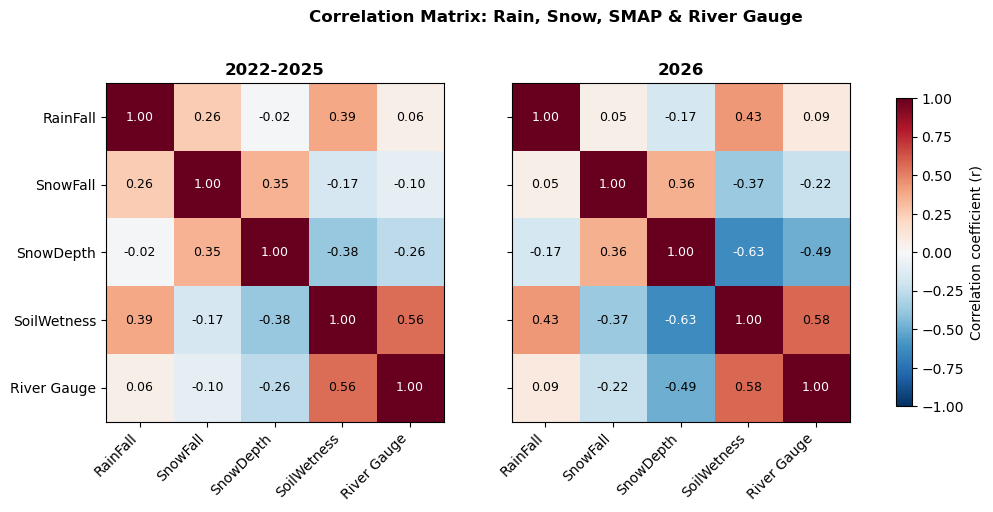

In [6]:
numbers = ["RainFall","SnowFall","SnowDepth","SoilWetness","River Gauge"]
fig, axes = plt.subplots(1,2, figsize=(12,5))

for ax, (data, title) in zip(axes, [(df_2022, "2022-2025"), (df_2026, "2026")]):
    corr = data[numbers].corr()

    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_yticks(range(len(corr.columns)))
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticklabels(corr.columns)
    if ax == axes[0]:
        ax.set_yticklabels(corr.columns)
    else:
        ax.set_yticklabels([])
    ax.set_title(title, fontweight="bold")

    for i in range(len(corr.columns)):
        for j in range(len(corr.columns)):
            val = corr.iloc[i, j]
            color = "white" if abs(val) > 0.6 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=9)
 
fig.suptitle("Correlation Matrix: Rain, Snow, SMAP & River Gauge", fontweight="bold")
fig.colorbar(im, ax=axes, shrink=0.8, label="Correlation coefficient (r)")
fig.savefig("correlation_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

Saved: scatter_smap.png


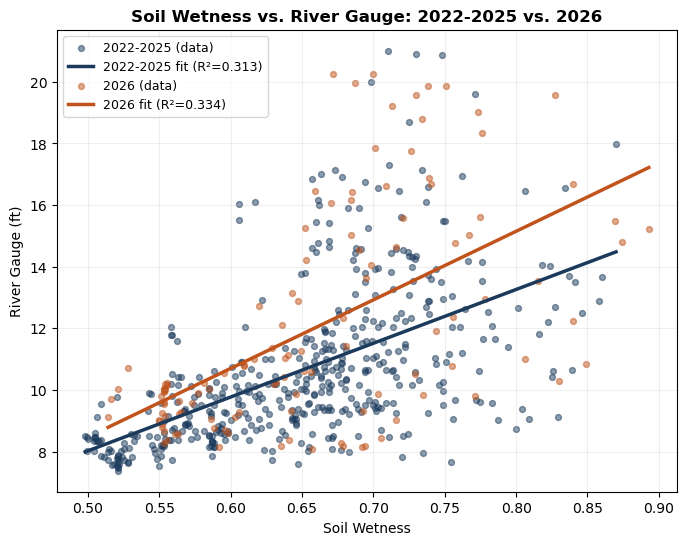

In [10]:
fig, ax = plt.subplots(figsize=(8,6))

for data, color, label in [
    (df_2022, "#1b3a5c", "2022-2025"),
    (df_2026, "#c1541c", "2026"),
]:
    
    ax.scatter(data["SoilWetness"], data["River Gauge"], s=18, alpha=0.5,
               color=color, label=f"{label} (data)")

    
    X = sm.add_constant(data["SoilWetness"])
    model = sm.OLS(data["River Gauge"], X).fit()

    
    xs = np.linspace(data["SoilWetness"].min(), data["SoilWetness"].max(), 100)
    ys = model.params["const"] + model.params["SoilWetness"] * xs
    ax.plot(xs, ys, color=color, linewidth=2.5,
            label=f"{label} fit (R\u00b2={model.rsquared:.3f})")

ax.set_xlabel("Soil Wetness")
ax.set_ylabel("River Gauge (ft)")
ax.set_title("Soil Wetness vs. River Gauge: 2022-2025 vs. 2026", fontweight="bold")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.2)

fig.savefig("scatter_smap.png", dpi=200)


print("Saved: scatter_smap.png")
